# Arabic PDF Layout + OCR Model Survey

Pick a PDF, render pages, run candidate **layout** models, crop regions, run
candidate **OCR** models on each crop, eyeball results, pick winners,
assemble a markdown file.

**How to use:**
1. Set `PDF_PATH` and `PAGES` in the Config cell.
2. Toggle which layout/OCR models to try in the registry cells.
3. Run cells top-to-bottom. Results cached on disk in `notebooks/.cache/`.
4. After eyeballing, set `WIN_LAYOUT` + `WIN_OCR` in the **Pick winners** cell.
5. Run the assemble cell — produces `out/transcript.md`.

## 1. Imports & device

In [1]:
import os, sys, json, hashlib, time, traceback, gc
from pathlib import Path
from dataclasses import dataclass, field
from typing import Callable, Any
import torch
from PIL import Image, ImageDraw, ImageFont
from IPython.display import HTML, display

NB_DIR = Path.cwd()
if NB_DIR.name != "notebooks":
    NB_DIR = Path("notebooks").resolve() if (Path.cwd() / "notebooks").exists() else NB_DIR
CACHE = NB_DIR / ".cache"
OUT = NB_DIR / "out"
CACHE.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN") or ""
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN

print(f"device={DEVICE} dtype={DTYPE} cache={CACHE} hf_token={'set' if HF_TOKEN else 'missing'}")

device=cuda dtype=torch.float16 cache=/home/abdullah/Documents/hdd/arabic-pdf-trascriber/notebooks/.cache hf_token=set


## 2. Config — PDF + pages

In [2]:
PDF_PATH = Path("/home/abdullah/Downloads/بناء الأجيال_Foulabook.com_.pdf")
PAGES = [1, 26, 30, 46, 48, 55, 77, 82, 90, 159, 183, 193]  # 12 pages: 1, 30, +10 random (seed=42)
DPI = 200
CROP_PAD = 8

assert PDF_PATH.exists(), f"PDF not found: {PDF_PATH}"
print(f"pdf={PDF_PATH.name} pages={PAGES} dpi={DPI}")

pdf=بناء الأجيال_Foulabook.com_.pdf pages=[1, 26, 30, 46, 48, 55, 77, 82, 90, 159, 183, 193] dpi=200


## 3. Cache helpers

In [3]:
def _hash(*parts) -> str:
    h = hashlib.sha256()
    for p in parts:
        if isinstance(p, bytes):
            h.update(p)
        elif isinstance(p, Path):
            h.update(str(p).encode()); h.update(str(p.stat().st_mtime).encode())
        else:
            h.update(str(p).encode())
    return h.hexdigest()[:16]

def cache_path(kind: str, key: str, ext: str) -> Path:
    d = CACHE / kind
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{key}.{ext}"

def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def to_inference(m):
    m.train(False)
    return m

## 4. Render PDF pages → PNG (cached)

page 1: (506, 709)
page 26: (1653, 2339)
page 30: (1653, 2339)
page 46: (1653, 2339)
page 48: (1653, 2339)
page 55: (1653, 2339)
page 77: (1653, 2339)
page 82: (1653, 2339)
page 90: (1653, 2339)
page 159: (1653, 2339)
page 183: (1653, 2339)
page 193: (1653, 2339)


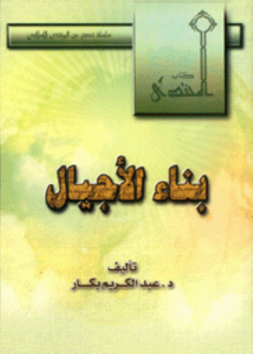

In [4]:
from pdf2image import convert_from_path

def render_page(pdf: Path, page: int, dpi: int) -> Image.Image:
    key = _hash(pdf, page, dpi)
    png = cache_path("pages", key, "png")
    if png.exists():
        return Image.open(png).convert("RGB")
    imgs = convert_from_path(str(pdf), dpi=dpi, first_page=page, last_page=page)
    img = imgs[0].convert("RGB")
    img.save(png)
    return img

PAGE_IMAGES: dict[int, Image.Image] = {p: render_page(PDF_PATH, p, DPI) for p in PAGES}
for p, im in PAGE_IMAGES.items():
    print(f"page {p}: {im.size}")
display(PAGE_IMAGES[PAGES[0]].resize((PAGE_IMAGES[PAGES[0]].width // 2, PAGE_IMAGES[PAGES[0]].height // 2)))

## 5. Layout model registry

In [5]:
LAYOUT_REGISTRY: dict[str, dict] = {}

def register_layout(name: str):
    def deco(fn):
        LAYOUT_REGISTRY[name] = {"name": name, "loader": fn}
        return fn
    return deco

@register_layout("full-page")
def _load_full_page():
    """Pseudo-layout: whole page is one region. Use with vision-LLM OCR
    that handles internal layout."""
    def infer(image: Image.Image):
        return [{"bbox": [0, 0, image.width, image.height], "label": "page"}]
    return infer

@register_layout("doclayout-yolo")
def _load_doclayout_yolo():
    from doclayout_yolo import YOLOv10
    from huggingface_hub import hf_hub_download
    path = hf_hub_download(
        repo_id="juliozhao/DocLayout-YOLO-DocStructBench",
        filename="doclayout_yolo_docstructbench_imgsz1024.pt",
    )
    model = YOLOv10(path)
    def infer(image: Image.Image):
        res = model.predict(image, imgsz=1024, conf=0.25, device=DEVICE)
        out = []
        for r in res:
            names = r.names
            for box, cls in zip(r.boxes.xyxy.tolist(), r.boxes.cls.tolist()):
                out.append({"bbox": [int(v) for v in box], "label": names[int(cls)]})
        return out
    return infer

@register_layout("surya")
def _load_surya_layout():
    from surya.layout import LayoutPredictor
    from surya.foundation import FoundationPredictor
    fp = FoundationPredictor()
    pred = LayoutPredictor(fp)
    def infer(image: Image.Image):
        res = pred([image])[0]
        out = []
        for b in res.bboxes:
            out.append({"bbox": [int(v) for v in b.bbox], "label": b.label})
        return out
    return infer

print("registered layout models:", list(LAYOUT_REGISTRY.keys()))

registered layout models: ['full-page', 'doclayout-yolo', 'surya']


## 6. OCR model registry

In [6]:
OCR_REGISTRY: dict[str, dict] = {}

def register_ocr(name: str):
    def deco(fn):
        OCR_REGISTRY[name] = {"name": name, "loader": fn}
        return fn
    return deco

def _vlm_generate(model_box: list, proc, image, prompt, max_new_tokens=768):
    """Generate with OOM fallback to CPU. model_box is [model] so we can swap."""
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt},
    ]}]
    text = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    model = model_box[0]
    target_dev = next(model.parameters()).device.type
    try:
        inputs = proc(text=[text], images=[image], return_tensors="pt").to(target_dev)
        with torch.inference_mode():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        gen = out[:, inputs.input_ids.shape[1]:]
        return proc.batch_decode(gen, skip_special_tokens=True)[0].strip()
    except torch.cuda.OutOfMemoryError:
        print("  [OOM on GPU — moving model to CPU and retrying]")
        free_gpu()
        model = model.cpu().to(torch.float32)
        model_box[0] = model
        inputs = proc(text=[text], images=[image], return_tensors="pt")
        with torch.inference_mode():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        gen = out[:, inputs.input_ids.shape[1]:]
        return proc.batch_decode(gen, skip_special_tokens=True)[0].strip()

@register_ocr("qwen2-vl-2b")
def _load_qwen2_vl_2b():
    from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
    repo = "Qwen/Qwen2-VL-2B-Instruct"
    proc = AutoProcessor.from_pretrained(
        repo, min_pixels=256 * 28 * 28, max_pixels=512 * 28 * 28
    )
    model = to_inference(Qwen2VLForConditionalGeneration.from_pretrained(
        repo, torch_dtype=DTYPE
    ).to(DEVICE))
    box = [model]
    PROMPT = "Extract all text from this image as plain Arabic. Output only the text, no commentary."
    def infer(image: Image.Image) -> str:
        return _vlm_generate(box, proc, image, PROMPT)
    def _cleanup():
        try: box[0].cpu()
        except Exception: pass
        free_gpu()
    infer._cleanup = _cleanup
    return infer

@register_ocr("qari-ocr")
def _load_qari_ocr():
    from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
    repo = "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct"
    proc = AutoProcessor.from_pretrained(
        "Qwen/Qwen2-VL-2B-Instruct",
        min_pixels=256 * 28 * 28, max_pixels=512 * 28 * 28,
    )
    model = to_inference(Qwen2VLForConditionalGeneration.from_pretrained(
        repo, torch_dtype=DTYPE
    ).to(DEVICE))
    box = [model]
    PROMPT = "Below is the image of one page of a document, please read the content and convert it into plain text."
    def infer(image: Image.Image) -> str:
        return _vlm_generate(box, proc, image, PROMPT)
    def _cleanup():
        try: box[0].cpu()
        except Exception: pass
        free_gpu()
    infer._cleanup = _cleanup
    return infer

@register_ocr("surya")
def _load_surya_ocr():
    from surya.recognition import RecognitionPredictor
    from surya.detection import DetectionPredictor
    from surya.foundation import FoundationPredictor
    fp = FoundationPredictor()
    rec = RecognitionPredictor(fp)
    det = DetectionPredictor()
    def infer(image: Image.Image) -> str:
        res = rec([image], det_predictor=det)[0]
        return "\n".join(line.text for line in res.text_lines)
    def _cleanup():
        free_gpu()
    infer._cleanup = _cleanup
    return infer

# --- Tesseract (CPU baseline; fast, classic OCR) ---
@register_ocr("tesseract-ara")
def _load_tesseract_ara():
    import pytesseract
    os.environ["TESSDATA_PREFIX"] = "/home/abdullah/.tessdata"
    def infer(image: Image.Image) -> str:
        return pytesseract.image_to_string(image, lang="ara").strip()
    return infer

# --- EasyOCR (Arabic) ---
@register_ocr("easyocr-ara")
def _load_easyocr_ara():
    import easyocr
    import numpy as np
    reader = easyocr.Reader(["ar"], gpu=(DEVICE == "cuda"))
    def infer(image: Image.Image) -> str:
        arr = np.array(image)
        results = reader.readtext(arr, detail=1, paragraph=True)
        return "\n".join(r[1] for r in results)
    def _cleanup():
        free_gpu()
    infer._cleanup = _cleanup
    return infer

# --- PaddleOCR Arabic ---
@register_ocr("paddleocr-ara")
def _load_paddleocr_ara():
    from paddleocr import PaddleOCR
    import numpy as np
    # PaddleOCR 3.x needs explicit ocr_version for non-default langs; "arabic" via PP-OCRv3
    # PaddleOCR 3.x: Arabic via "ar" lang code → arabic_PP-OCRv3_mobile_rec
    ocr = PaddleOCR(lang="ar", ocr_version="PP-OCRv3",
                    use_textline_orientation=False,
                    use_doc_orientation_classify=False, use_doc_unwarping=False)
    def infer(image: Image.Image) -> str:
        arr = np.array(image)
        result = ocr.predict(arr)
        lines = []
        for page in result:
            texts = page.get("rec_texts", []) if isinstance(page, dict) else getattr(page, "rec_texts", [])
            lines.extend(texts)
        return "\n".join(lines)
    def _cleanup():
        free_gpu()
    infer._cleanup = _cleanup
    return infer

# --- Qwen2.5-VL-3B-Instruct (newer base VLM) — runs on CPU on 6GB GPU ---
@register_ocr("qwen2.5-vl-3b")
def _load_qwen25_vl_3b():
    from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
    repo = "Qwen/Qwen2.5-VL-3B-Instruct"
    proc = AutoProcessor.from_pretrained(
        repo, min_pixels=256 * 28 * 28, max_pixels=512 * 28 * 28
    )
    # 3B model > 5.6GB GPU — load on CPU directly
    model = to_inference(Qwen2_5_VLForConditionalGeneration.from_pretrained(
        repo, torch_dtype=torch.float32
    ).to("cpu"))
    box = [model]
    PROMPT = "Extract all Arabic text from this image. Output only the text, no commentary."
    def infer(image: Image.Image) -> str:
        return _vlm_generate(box, proc, image, PROMPT)
    def _cleanup():
        free_gpu()
    infer._cleanup = _cleanup
    return infer

print("registered OCR models:", list(OCR_REGISTRY.keys()))

registered OCR models: ['qwen2-vl-2b', 'qari-ocr', 'surya', 'tesseract-ara', 'easyocr-ara', 'paddleocr-ara', 'qwen2.5-vl-3b']


## 7. Run layout pass (cached per page × model)

In [7]:
def run_layout(model_name: str, page: int, image: Image.Image) -> list[dict]:
    key = _hash(model_name, PDF_PATH, page, DPI)
    js = cache_path("layout", key, "json")
    if js.exists():
        return json.loads(js.read_text())
    print(f"[layout] loading {model_name}...")
    t0 = time.time()
    infer = LAYOUT_REGISTRY[model_name]["loader"]()
    t_load = time.time() - t0
    t0 = time.time()
    boxes = infer(image)
    t_infer = time.time() - t0
    js.write_text(json.dumps(boxes, ensure_ascii=False))
    (cache_path("layout", key, "meta.json")).write_text(json.dumps({
        "model": model_name, "page": page, "load_s": t_load, "infer_s": t_infer, "n_boxes": len(boxes)
    }))
    print(f"[layout] {model_name} page={page} load={t_load:.1f}s infer={t_infer:.1f}s boxes={len(boxes)}")
    free_gpu()
    return boxes

LAYOUT_TRY = ["full-page", "doclayout-yolo", "surya"]
LAYOUT_RESULTS: dict[tuple[str, int], list[dict]] = {}
for name in LAYOUT_TRY:
    for p in PAGES:
        LAYOUT_RESULTS[(name, p)] = run_layout(name, p, PAGE_IMAGES[p])

## 8. Visualize layout overlays

In [8]:
def overlay_boxes(image: Image.Image, boxes: list[dict], color="red") -> Image.Image:
    im = image.copy()
    draw = ImageDraw.Draw(im)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 18)
    except Exception:
        font = ImageFont.load_default()
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = b["bbox"]
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1 + 4, y1 + 4), f"{i}:{b['label']}", fill=color, font=font)
    return im

for p in PAGES:
    cols = []
    for name in LAYOUT_TRY:
        ov = overlay_boxes(PAGE_IMAGES[p], LAYOUT_RESULTS[(name, p)])
        path = OUT / f"layout_{name}_p{p}.png"
        ov.save(path)
        scaled = ov.resize((ov.width // 2, ov.height // 2))
        buf_path = OUT / f"_thumb_layout_{name}_p{p}.png"
        scaled.save(buf_path)
        cols.append((name, buf_path))
    html = "<table><tr>"
    for name, path in cols:
        html += f"<td style='text-align:center'><b>{name}</b><br><img src='{path.as_posix()}' style='max-width:500px'></td>"
    html += "</tr></table>"
    display(HTML(html))

full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


...

full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


full-page,doclayout-yolo,surya


## 9. Crop regions (per layout model)

In [9]:
CROP_LAYOUT = "full-page"

def crop_regions(image: Image.Image, boxes: list[dict], pad: int) -> list[Image.Image]:
    crops = []
    W, H = image.size
    for b in boxes:
        x1, y1, x2, y2 = b["bbox"]
        x1 = max(0, x1 - pad); y1 = max(0, y1 - pad)
        x2 = min(W, x2 + pad); y2 = min(H, y2 + pad)
        crops.append(image.crop((x1, y1, x2, y2)))
    return crops

CROPS: dict[int, list[Image.Image]] = {}
for p in PAGES:
    boxes = LAYOUT_RESULTS[(CROP_LAYOUT, p)]
    CROPS[p] = crop_regions(PAGE_IMAGES[p], boxes, CROP_PAD)
    print(f"page {p}: {len(CROPS[p])} crops from {CROP_LAYOUT}")

for i, c in enumerate(CROPS[PAGES[0]][:6]):
    print(f"crop {i}: {c.size}")

page 1: 1 crops from full-page
page 26: 1 crops from full-page
page 30: 1 crops from full-page
page 46: 1 crops from full-page
page 48: 1 crops from full-page
page 55: 1 crops from full-page
page 77: 1 crops from full-page
page 82: 1 crops from full-page
page 90: 1 crops from full-page
page 159: 1 crops from full-page
page 183: 1 crops from full-page
page 193: 1 crops from full-page
crop 0: (506, 709)


## 10. Run OCR per crop × model (cached)

In [10]:
def crop_key(image: Image.Image) -> str:
    import io
    buf = io.BytesIO(); image.save(buf, format="PNG")
    return _hash(buf.getvalue())

def run_ocr_one(model_name: str, infer: Callable, image: Image.Image) -> str:
    ck = crop_key(image)
    key = _hash(model_name, ck)
    txt = cache_path("ocr", key, "txt")
    if txt.exists():
        return txt.read_text()
    t0 = time.time()
    try:
        out = infer(image)
    except Exception as e:
        out = f"<<ERROR {model_name}: {e}>>"
        traceback.print_exc()
    dt = time.time() - t0
    txt.write_text(out)
    (cache_path("ocr", key, "meta.json")).write_text(json.dumps({
        "model": model_name, "crop_key": ck, "infer_s": dt, "len": len(out)
    }))
    return out

OCR_TRY = ["surya", "tesseract-ara", "easyocr-ara", "qari-ocr", "qwen2-vl-2b"]
# Skipped:
#   paddleocr-ara — paddlepaddle/paddlex API mismatch (set_optimization_level)
#   qwen2.5-vl-3b — too big for 6GB GPU + 32GB RAM (kernel died on CPU fp32)

OCR_RESULTS: dict[tuple[str, int, int], str] = {}

for model_name in OCR_TRY:
    print(f"\n=== {model_name} ===")
    needs_load = False
    for p in PAGES:
        for i, _ in enumerate(CROPS[p]):
            ck = crop_key(CROPS[p][i])
            if not cache_path("ocr", _hash(model_name, ck), "txt").exists():
                needs_load = True; break
        if needs_load: break
    infer = None
    if needs_load:
        t0 = time.time()
        infer = OCR_REGISTRY[model_name]["loader"]()
        print(f"loaded in {time.time()-t0:.1f}s")
    try:
        for p in PAGES:
            for i, crop in enumerate(CROPS[p]):
                if infer is None:
                    OCR_RESULTS[(model_name, p, i)] = run_ocr_one(model_name, lambda x: "", crop)
                else:
                    OCR_RESULTS[(model_name, p, i)] = run_ocr_one(model_name, infer, crop)
                preview = OCR_RESULTS[(model_name, p, i)].replace("\n", " ")[:60]
                print(f"  p{p} crop{i}: {preview}")
    finally:
        if infer is not None and hasattr(infer, "_cleanup"):
            infer._cleanup()
        del infer
        free_gpu()


=== surya ===


  p1 crop0: بناه النجيال د.عبدالكريميكار
  p26 crop0: باء الأج ال الشيء، ويرى آخرين يفعلون ضده، فإنه سيتكوَّن لديه


  p30 crop0: ___ باء الأج ___ال _صلى الله عليه وسلم_، وقد خلق الله السموا
  p46 crop0: البية البية 51 البية البية إن كل واحد من بني البشر مدين في ت


  p48 crop0: البية البية 53 يمتلك الأطفال والفتيان درجة عالية من البراءة،
  p55 crop0: باء الأجيال _ نستمع وننصت للآخرين. _ نعمل معًا. _ كلنا فريق 


  p77 crop0: د ــــاء العقــ يسمعونه على علاته، وإنما يحاولون تقييمه والب
  p82 crop0: جيل يع ف تعليم القراءة في وقت مبكر: يبدو أن عزوف الأبناء وال


...

  p30 crop0: لـَّمْجَلْلا َءَءَـِبٍ ٣٤ فاَّرَتْعَلاَو ، َقَلْحَب َضْرَّلْ
  p46 crop0: (10,10),(989,987)


  p48 crop0: 53 ةيبرلا ةيبللا ، رابكلااب نوقيت مهف ، ةدارلا نم ةيلاع ةجرد
  p55 crop0: (10,10),(990,987)


  p77 crop0: 83 ِءاَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـَـ
  p82 crop0: 89


  p90 crop0: 97
  p159 crop0: 


  p183 crop0: (193,10),(899,987)
  p193 crop0: (143,101),(807,127)


## 11. Side-by-side comparison (RTL Arabic display)

In [11]:
def render_compare(page: int) -> str:
    crops = CROPS[page]
    thumbs = []
    for i, c in enumerate(crops):
        t = OUT / f"_thumb_p{page}_c{i}.png"
        c.save(t)
        thumbs.append(t)
    style = (
        "table{border-collapse:collapse;font-family:sans-serif;}"
        "td,th{border:1px solid #888;padding:6px;vertical-align:top;}"
        ".ar{direction:rtl;text-align:right;font-family:'Amiri','Noto Naskh Arabic',serif;font-size:14px;max-width:400px;}"
        "img{max-width:280px;}"
    )
    html = f"<style>{style}</style><table><thead><tr><th>#</th><th>crop</th>"
    for m in OCR_TRY:
        html += f"<th>{m}</th>"
    html += "</tr></thead><tbody>"
    for i, c in enumerate(crops):
        html += f"<tr><td>{i}</td><td><img src='{thumbs[i].as_posix()}'></td>"
        for m in OCR_TRY:
            txt = OCR_RESULTS.get((m, page, i), "")
            html += f"<td class='ar'>{txt[:500]}</td>"
        html += "</tr>"
    html += "</tbody></table>"
    return html

for p in PAGES:
    display(HTML(f"<h3>Page {p} — layout: {CROP_LAYOUT}</h3>"))
    display(HTML(render_compare(p)))

#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,بناه النجيال د.عبدالكريميكار,,ل ئد لأجيل دلف دء عبد الكربه بسد,بِناء الأجيالتَأْيِفد .عبد الكريم بكَار,بناء الأجيال


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,باء الأج ال الشيء، ويرى آخرين يفعلون ضده، فإنه سيتكوَّن لديه انطباع بأن هذا الفعل _وليكن الصدق_ مقبول، وهذا الفعل _وليكن الكذب_ أيضًا مقبول، وبذلك تختلط عليه الأمور، فيقلد هذا الكبير تارة وذلك الكبير تارة أخرى. إن تأكيد الهدي النبوي على ضرورة الامتناع عن ارتكاب المنهيات والوقوع في المحظورات يهدف فيما يهدف إليه _ إلى أن يكون الخطأ واضحًا في أذهان الأطفال على نحو لا لبس فيه؛ وبذلك يتأسس لديه نظام القيم، ويصبح الوقوع في الخطأ سببًا لتأنيب الضمير ولوم النفس. قال _عليه الصلاة والسلام_: «ما نهيتكم عنه,زا بسب اء الأجبال الشي ويرى آخرين يفعلون ضده؛ فإنه سيتكون لديه انطباع بأن هذا الفعل _وليكن الصدق_ مقبول» وهذا الفعل _وليكن الكذب_ أيضًا مقبول» وبذلك تختلط عليه الأمور» فيقلد هذا الكبير تارة وذلك الكبير تارة أخرى. إن تأكيد الهدي النبوي على ضرورة الامتناع عن ارتكاب المنهيات والوقوع في المحظورات يهدف فيما يهدف إليه _ إلى أن يكون الخطأً واضحًا في أذهان الأطفال على نحو لا لبس فيه؛ وبذلك يتأسس لديه نظام القيم» ويصبح الوقوع في الخطأ سببًا لتأنيب الضمير ولوم النفس. قال _عليه الصلاة والسلام. : «ما شهيت,الأج ال 30 الشيء( ويرى آخرين يفعلون ضده فإنه سيتكون لديه انطباع بأن هذا الفعل -وليكن الصدق مقبول وهذا الفعل _ وليكن الكذب _ أيضًا مقبول وبذلك تختلط عليه الأمور فيقلد هذا الكبير تارة وذلك الكبير تارة أخرى . إن تأكيد الهدي النبو ي على ضرورة الامتناع عن ارتكاب المنهيات والوقوع في المحظورات يهدف فيما يهدف إليه إلى أن يكون الخطأ واضحًا أذهان الأطفال على نحولا لبس فيه ; وبذلك يتأسس لديه نظام القيم ويصبح الوقوع في الخطأ سببًا لتأنيب الضمير ولوم النفس . قال عليه الصلاة _ السلام _ »ما نهيتكم عنه فاج,لـاللهأءاـ بـ ش يشلا،ء،يريو نيرخآ نولعفي نوكتيتس هنإف،هدض نولعفي قدصلا نكلو،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،,30 ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ ـ


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,___ باء الأج ___ال _صلى الله عليه وسلم_، وقد خلق الله السموات والأرض بالحق. والاعتراف بالحق والإذعان له، والتأثر بسبب الاهتداء إليه _ شأن من شؤون النفوس الكبيرة. وقد قصَّ الله _تعالى_ علينا نبأ القسيسين والرهبان الذين تفاعلوا مع الحق وأذعنوا له، وانحازوا إلى أهله حين قال: {وَلَتَجِدَنَّ أَقْرَبَهُم مَّوَدَّةً لَّلَّذِينَ آمَنُوا الَّذينَ قَالُوا إِنَّا نَصَارَى ذَلكَ بأَنَّ منْهُمْ قسِّيسينَ وَرُهْبَاناً وَأَنَّهُمْ لاَ يَسْتَكْبرُونَ ﴿82﴾ وَإِذَا سَمِعُوا مَا أُنزِلَ إِلَى الرَّسُولِ تَرَى أَعْ,زيح #“سسسصس_ م سس با الأجل _صلى الله عليه وسلم» وقد خلق الله السموات والأرض بالحق. والاعتراف بالحتى والإذعان له»؛ والتأثر بسبب الاهتداء إليه _ شأن من شؤون النفوس الكبيرة. وقد قصّ الله تعالى_ علينا نبأ القسيسين والرهبان الذين تفاعلوا مع الحق وأذعنوا له؛ وانحازوا إلى أهله حين قال: (وَلَتَجِدَنَ أَقَرَبَهُم مَوَدَةَ لَلَّدِينَ آمَنوا الَّذِينَ قَالُوا إن لصَارَى ذَلكَ بِأَنْ منْهُمْ قسَّسينَ وَرْهَْاناً وَآنَهُمْ لآ يَستَكِرُونَ (82» وَإذَا سَمعُوا ما أل إلى الرسُول كرى أَحنَهمْ فيض من الدع مما عَر,بء الأج ال 34 _ صلى الله عليه وسلم . وقد خلق الله السموا ات والأرض بالحق. والاعتراف بالحق والإذعان له، والتأثر بسبب الاهتداء إليه شأن من شؤون النفوس الكبيرة . وقد قصً الله _ تعالى _ علينا نبأ القسيسين والرهبان الذين تفاعلو مع الحق وأذعنو له، وانحازوا إلى أهله حين قال: } ولتجدن أقربهم مًودًةً للًذين آمنو الًذين قالوا إنًا نصارى ذلك بأًنً منهم قسًيسين ورهباناً وأنهم لا يستكبرون إ82< وإذا سمعوا ما أنزل إلى الرًسول ترى أعينهم تفيض من الدًمع ممًا عرفوا من الحق يًقولون ربًنًا آمًنًا فاكتبنًا مع الشًا,لـ جألا ءاـبـم34لـ ص للها الله الى ى الى ص فاترخلاا و ،قحاب ضرألأا و تاوممسلا للها قلخ هدقو ،ملمسو هيلع للها ى لى الى ى ص فاونعمسلا و ،هل ناعذلاا و قحاب سونفلا نوؤش نم نأش و هيلإ هادتهلاا ببسب ثرأتلاا و هل ناعذلاا و قحاب عم اولعافت نيدلا نايبرلاو نيسيسقلا أبنت اليلع لىاعت للها ىصق هدقو ،ةريبك,لـَّمْجَلْلا َءَءَـِبٍ ٣٤ فاَّرَتْعَلاَو ، َقَلْحَب َضْرَّلْلاَو تَاَوَمْسَلا َالْلَّلا َقَلِخ َدَقَو ، ِمَلْسَو ِهِلْعَع َالْلَّلا َلِىَص . ِهِلْيَإ ِءَاَدَتْهَلْلا ِبَسْبَب ِرَثْأَتْلاَو ِهَل ِنَاَعَذْلْلاَو َقَلْحَب ِسْوَفْنَلا َنْوُؤْش َنِم َنْأَش َّمَلَعَتْلاَو َهِلْيَإ ِهِلْعَع َالْلَّلا َقَلِخَب ِعَم ِاَوْلَعَافَتِ ِنِيْذَلْلا ِنَاَيْهَرْلاَو ِنِيَسْيَسْقَلا ًأَبِن ِاَنْيَلَعَتْلاَو َلَّعَتْلاَو َهِلْيَإ ِهِلْعَع َالْلَّلا َقَلِخَب ِنِيْذَلْلا َنْوُرْيَكَتْسَي ْلا َمْهُّنْلاَو َنَأَنْهَزْ


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,البية البية 51 البية البية إن كل واحد من بني البشر مدين في تركيبته العقلية والنفسية والبدنية وفي علاقاته الاجتماعية لأمرين جوهريين؛ هما الوراثة والبيئة. ففي طريق التفاعل النشط جدًا والغامض جدًّا بين ما ورثناه عن آبائنا وأجدادنا وبين مجموعة المعطيات التي وفرها عيشنا في مجتمع _ يبرز إلى الوجود نسخة مستقلة متميزة من ولد آدم لا تكاد تتطابق مع أي نسخة أخرى. وإذا كنا لا نملك أي خيار حيال ما ورثناه عن أسلافنا، فإننا نملك الكثير الكثير مما يمكن أن نفعله تجاه البيئة التي ننشِّع فيها صغارنا. لكن بما أن ال,البية ال باية © البية ال با ية إن كل واحد من بي البشر مدين في تركيبته العقلية والنفسية والبدنية وفي علاقاته الاجتماعية لأمرين جوهريين؛ هما الوراثة والبيئة. ففى طريق التفاعل النشط جدًا والغامض جدَا بين ما ورثناه عن آباثنا وأجدادنا وبين مجموعة المعطيات الي وفرها عيشنا في بجتمع - يرز إلى الوجود نسخة مستقلة متميزة من ولد آدم لا تكاد تتطابق مع أي نسخة أخرى. وإذا كنا لا ثملك أي خيار حيال ما ورثناه عن أسلافنا» فإننا نملك الكثير الكثير مما يمكن أن نفعله اه البيئة الي ننشّئ فيها صغارنا. لكن يما أن التع,البية ال بية 51 البية ال ب ية إن كل واحد من بني البشر مدين في تركيبته العقلية والنفسية والبدنية وفي علاقاته الاجتماعية لأمرين جوهريين ; هما الوراثة والبيئة ففي طريق التفاعل النشط جدًا والغامض جدًا بين ما ورثناه عن آبائنا وأجدادنا وبين مجموعة المعطيات التي وفرها عيشنا في مجتمع يبرز إلى الوجود نسخة مستقلة متميزة من ولد آدم لا تكاد تتطابق مع أي نسخة أخرى . وإذا كنا ٧ نملك أي خيار حيال ما ورثناه عن أسلافناء فإننا نملك الكثير الكثير مما يمكن أن نفعله تجاه البيئة التي ننشئ فيها صغارنا لكن بما أن التع,ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة ة,"(10,10),(989,987)"


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,البية البية 53 يمتلك الأطفال والفتيان درجة عالية من البراءة، فهم يثقون بالكبار، ويعتقدون بصدق ما يقولونه، ويستغربون ما يرونه من تصدع بين الأقوال والأفعال في سلوكات الكبار؛ ويقفون في البداية موقف الحائر المتردد العاجز عن الفهم والتأويل. ومع مرور الأيام تتضح الصورة أمامهم؛ حيث يدركون أنه ليس على المرء أن يحمل كل ما يقال على محمل الجد، وألا يفهمه فهمًا حرفيًّا، بل يتضح لديهم أن التطابق بين الأقوال والأفعال لا يكون موجودًا دائمًا! وحين ينتظم الأطفال والفتيان في الدراسة، ويشرعون في التفاعل مع المواد,البية ال باية 3 يمتلك الأطفال والفتيان درجة عالية من البراءة» فهم يثقون بالكبار ويعتقدون بصدق ما يقولونه»؛ ويستغربون ما يرونه من تصدع بين الأقوال والأفعال في سلوكات الكبار؛ ويقفون في البداية موقف الحائر المتردد العاجز عن الفهم والتأويل. ومع مرور الأيام تتضح الصورة أمامهم؛ حيث يدركون أنه ليس على المرء أن يحمل كل ما يقال على محمل الحدء وألا يفهمه فهمًا حرفا بل يتضح لديهم أن التطابق بين الأقوال والأفعال لا يكون موجودًا دائمًا! وحين ينتظم الأطفال والفتيان في الدراسة» ويشرعون في التفاعل مع المواد وا,53 البية ال بية يمتلك الأطفال والفتيان درجة عالية من البراءة فهم يثقون بالكبار ويعتقدون بصدق ما يقولونه ويستغربون ما يرونه من تصدع بين الأقوال والأفعال في سلوكات الكبار ; ويقفون في البداية موقف الحائر المتردد العاجز عن الفهم والتأويل . ومع مرور الأيام تتضح الصورة أمامهم ; حيث يدركون أنه ليس على المرءأن يحمل كل مايقال على محمل الجدء وألا يفهمه فهمًا حرفيًا بل يتضح لديهم أن التطابق بين الأقوال والأفعال لا يكون مو جودًا دائمًا ! وحين ينتظم الأطفال _الفتيان في الدراسة ويشرعون في التفاعل مع,53، ةيد لا ةدلبلا ، راكيلاب نوقثي مهف ، ةءاربل نم للاغطلأا ككلتم ميمت نودقتعبو و لاقفلأا نيب عدصتب نم هنوبري ام نوبرغتسيو ، هنووقفي ام قدصي نم نودقتعبو و لاقفلأا نيب نع زجاعلا ددترالا مئاخلا فقوم ةيادلبلا في نوقفتيو ؛راكيللا تاكولس في لاعفلأا و مهفلا نيب لولاثلاو مهفلا و لاعفلأا نيب قباطنلا نأ زنلما لىع سيل و مهمامأ ةرورصلا حضتتب هنأ نوكردبي ثيح ؛مهمامأ و مهفلا,53 ةيبرلا ةيبللا ، رابكلااب نوقيت مهف ، ةدارلا نم ةيلاع ةجرد نايتفلاو لافطلأا كلتمي ، هنولوقي ام قدص نودقتعبو ، لاوقفلأا نيب عدصت نم هنوري ام نوبرغتسيو ، نع زجاعلا ددرتسلا رئالخا فقوم ةيادبلا في نوقيقيو ةرابكلا تاكولس في لاعفلأاو ، ليوأتلاو مهفلا ، هنأ نوكردبي ثيح ، مهمامأ ةروصلا حضتت مايلأا رورم عمو ، اًيفرح اًمهف همهفيي لاوأو ، دلجا لمعي لىع لاقبي ام لك لمعت نأ ءزملل لىع سيل ، اًيفرح اًمهف همهفيي لاوأو ، لافطلأا نيب قباطنلا نأ مهيدل حضتي لب ، نيحو !امثاد اًدوجرم نوكي لا لافطلأاو لاوقفلأا مظنتي


...

#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,جيل يع ف تعليم القراءة في وقت مبكر: يبدو أن عزوف الأبناء والآباء عن ممارسة القراءة يعود إلى القصور الذي اعترى النشأة الأولى في المترل؛ إذ إن العناية بتأسيس التوجه المعرفي لدى الأطفال في سن مبكرة شبه معدومة، فنحن نعتقد أن الطفل في السنوات الثلاث أو الأربع الأولى، يتأبي على إيصال أي أفكار أو معلومات ذات قيمة إليه. وكثير من الآباء الذين يعتقدون أنهم يملكون رؤى تربوية جيدة يرون أن الأطفال في سنواهم الأولى لا يحتاجون إلا إلى العطف واللعب. ومع أن هذين الأمرين مهمان جدًّا إلا أن في الإمكان أيضًا توجيه,جيل يء ف تعليم القراءة في وقت مبكر: يدو أن عزوف الأبناء والآباء عن ممارسة القراءة يعود إلى القصور الذي اعترى النشأة الأولى في المتزل؛ إذ إن العناية بتأسيس التوجه المعرقي لدى الأطفال في سن مبكرة شبه معدومة» فنحن نعتقد أن الطفل في السنوات الثلاث أو الأربع الأولى» يتأبى على إيصال أي أفكار أو معلومات ذات قيمة إليه. وكثير من الآباء الذين يعتقدون أنهم يملكون رؤى تربوية جيدة يرون أن الأطفال في سنواهم الأول لا يحتاجون إلا إلى العطف واللعب. ومع أن هذين الأمرين مهمان جد إلا أن في الإمكان أيضًا توجيه الموق,89 جيل يع ف تعليم القراءة في وقت مبكر : يبدو أن عزوف الأبناء والآباء عن ممارسة القراءة يعود إلى القصور الذي اعترى النشأة الأولى في المترل; إذ إن العناية بتأ سيس التوجه المعرفي لدى الأطفال سن مبكرة شبه معدومة فنحن نعتقد أن الطفل في السنو ات الثلاث أو الأربع الأولى ( يتأبى على إيصال أي أفكار أو معلومات ذات قيمة إليه. وكثير من الآباء الذين يعتقدون أنهم يملكون رؤى تربوية جيدة يرون أن الأطفال ثي سنواتهم الأولى ا يحتاجون إلا إلى العطف واللعب. ومع أن هذين الأمرين مهمان جدًا إلا أن في الإمكان أيضًا توج,89 ف بع ليب م : ركبم تقو ف ةءارقلا ميلعتيذلا روصقلا لىإ دوعي ةءارقلا السرام نع ءابآلاو ءابنآلا فورع نأ ودبي لزنلا في لولآا ةأشنلا ىرتعا لافظألا ىدل فيرعملا الحوجتلا سيسأتب ةياعنلا نإ ذإ ؛ لزنلا في لولآا ةركبم نس في ثلاثلا تاونسلا في لفظلا نأ دقتعن نحنف ،ةمدومع هبش ةركبم نس في ريثك و هيلإ ةميق تاذ تامولعم و أ راكفأ يأ لاصيإ لىع ياتي في ،لولآا عيرلأا ركبم نأ نورب ةديح ة,89


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,جيل يع ف 97 ويحرسها، ويسعى إلى نفعها، كما أن عليه أن يعتقد أنه إذا لم يساعد نفسه لم يساعده أحد. وليست مهارة القراءة مستثناة من ذلك. ولذا فإن تثقيفنا لجيل المستقبل ينبغي أن يركز على تربية القارئ الجيد والنهم. وإن على الأهل في المترل أن يقوموا ببذر البذور الأولى للشغف بالمعرفة والاطلاع على الجديد. وعلى المؤسسات التعليمية أن تتولى رعاية النبتات الغضة. وإني أعتقد أن تمليك مهارات القراءة الجيدة أحدى على الطالب من تحفيظه متنًا من المتون أو ديوانًا من الدواوين، وأجدى عليه من أن نجلس معه الساعات الطويلة,جيل بو ف “سريب صورقه ويجرسهاء ويسعى إلى نفعهاء كما أن عليه أن يعتقد أنه إذا لم يساعد نفسه لم يساعده أحد. وليست مهارة القراءة مستثناة من ذلك. ولذا فإن تثقيفنا لجيل المستقبل ينبغي أن يركز على تربية القارئ الجيد والنهم. وإن على الأهل في المتزل أن يقوموا ببذر البذور الأولى للشغف بالمعرفة والاطلاع على الجديد. وعلى المؤسسات التعليمية أن تتولى رعاية النبتات الغضة. وإني أعتقد أن تمليك مهارات القراءة الخيدة أجدى على الطالب من تحفيظه متنا من المتون أو ديوانًا من الدواوين» وأجدى عليه من أن نجلس معه الساعا,97 جيل يع ف ويحرسهاء ويسعى إلى نفعهاء كماأن عليه أن يعتقد أنه إذا لم يساعد نفسه يساعده أحد . وليست مهارة القراءة مستثناة من ذلك ولذا فإن تثقيفنا لجيل المستقبل ينبغي أن يركز على تربية القارئ الجيد والنهم. وإن على الأهل ثفي المترل أن يقومو ببذر البذور الأولى للشغف بالمعرفة والاطلاع على الجديد . وعلى المؤسسات التعليمية أن تتولى رعاية النبتات الغضة . وإني أعتقد أن تمليك مهارات القراءة الجيدة أجدى على الطالب من تحفيظه متنًا من المتون أو ديوانًا من الدواوين وأجدى عليه من أن نجلس معه الساعات الطويلة,97 ف بع ليلج لم هل هسفن دعاسي لم إذإ هنأ دقتعي نأ هيلع نأ امك، اهعفنف لى ىعسو، اهسرخيو، اهعاسيو، اهسركيو، لم هل ليلج انفيفقت ناؤغ اذلو، كلذ نم ةانتتسم ةارقلا ةرارهم تسيلو، دحأ هدعاسيو، لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع لى لىع,97


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,__ باء الأجيال وحين يكون على المرء أن يختار بين شراء كتاب وجرعة دواء؛ فإنه سيختار قطعًا جرعة الدواء. وحين يُخَيُّر مدير مدرسة بين أن يجهز مدرسته بمعمل وبين أن يؤمِّن مقاعد لطلابها؛ فإنه سيختار قطعًا شراء المقاعد. وهكذا فقد اجتمع علينا عدوان لدو دان: أولهما: قصور في فهمنا لتحديات العصر وواجباته وفرصه، بالإضافة إلى عدم الاهتمام بالعلم وعدم إدراك قيمته الحقيقية. وثانيهما: هو عدم وجود الإمكانات المطلوبة _في كثير من الأحيان_ لتوفير وسائل التعليم الجيد!! وسائل تثقيف منافسة: كان الناس في البيوت يربون ف,اتتتسستتسسلسلسييت باء الأجيال وحين يكون على المرء أن يختار بين شراء كتاب وجرعة دواء؛ فإنه سيختار قطعًا جرعة الدواء. وحين يُخَيّرَ مدير مدرسة بين أن يجهز مدرسته بمعمل وبين أن يؤْمَّن مقاعد لطلابما؛ فإنه سيختار قطعًا شراء المقاعد. وهكذا فقد اجتمع علينا عدوَّان لدودان: أوهما: قصور في فهمنا لتحديات العصر وواجباته وفرصه؛ بالإضافة إل عدم الاهتمام بالعلم وعدم إدراك قيمته الحقيقية. وثانيهما: هو عدم وجود الإمكانات المطلوبة _في كثير من الأحيان. لتوفير وسائل التعليم الجيد!! وسائل تثقيف منافسة: كان النا,الأجي ال ب 168 وحين يكون على المرءأن يختار بين شراء كتاب وجرعة دواء; فإنه سيختار قطعًا جرعة الدواء. وحين يخير مدير مدرسة بين أن يجهز مدر سته بمعمل وبين أن يؤمن مقاعد لطلابهاب فإنه سيختار قطعًا شراء المقاعد وهكذا فقد اجتمع علينا عدوان لدودان : أولهما : قصور ثي فهمنا لتحديات العصر وواجباته وفر صه بالإضافة إلى عدم الاهتمام بالعلم وعدم إدراك قيمته الحقيقية . وثانيهما : هو عدم وجود الإمكانات المطلوبة _ في كثير من الأحيان _ لتوفير وسائل التعليم الجيدا ! وسائل تثقيف منافسة : كان الناس في البيوت يربون,168 لَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَاكْيَلْأا هَاَيِبِ رَا,


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,مل الأفرار والمقولات العامة 193 الأفار والمقولات العامة مل الفكرة أو المقولة العامة الصفحة - لن ندرك حاجتنا إلى المدارس الجيدة إلا إذا تصورنا جيلا من غير قراءة ولا كتابة.... 5 - إن العلم لا يجعل المسلم دائمًا أفضل التزامًا؛ ولكن يجعله عليي كل حال أكثر حساسية نحو مسائل التدين، والارتقاء الفكري والخلقي. ....والخلقي المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المناسبة المنا,"مذ الأ ار والمقولات العامة .دوي مذ الأ ار والمقولات العامة الفكرة أو المقولة العامة الصفحة - لن ندرك حاجتنا إلى المدارس الجيدة إلا إذا تصورنا جيلاً من غير - إن العلم لا يجعل المسلم دائمًا أفضل التزامًا؛ ولكن يجعله على كل حال أكثر حساسية نحو مسائل التدين» والارتقاء الفكري والخلقي. وتم مم ""© - في القرن الحادي والعشرين ستصبح مهارات قوة العمل والتعليم؛ هي السلاح التنافسي الأول» وليس الفروات الطبيعية م - إن الأمم الي تُعلم وتربي وتدرب بطريقة أفضل؛ هي الأمم المرشحة لأن تتبواً القمة 0 - صارت أهم",193 مد الأف ار والمقولات العامة الأفار والمقولات العامة الصفحة الفكرة أو المقولة العامة - لن ندرك حاجتنا إلى المدارس الجيدة إلا إذا تصورنا جيلا من غير قراءة ولا كتابة . 5 - إن العلم لا يجعل المسلم دائمًا أفضل التزامًاب ولكن يجعله علسى كل حال أكثر حساسية نحو مسائل التدين ( والارتقساء الفكسري والخلقي . في القرن الحادي والعشرين ستصبح مهارات قوة العمل والتعليم ب السلاح التناف سي الأول وليس الثروات الطبيعية - إن الأمم التي تعلًم وتربي وتدرب بطريقة أفضل ; هسي الأمم المرشحة لأن تتبو القمة - صارت أهم,م ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف أ ف,"(193,10),(899,987)"


#,crop,surya,tesseract-ara,easyocr-ara,qari-ocr,qwen2-vl-2b
0,,مل الأفار والمقولات العامة 203 84 شيء استراتيجي في حياتهم..... - علينا أن نحوِّل الحديث عن سمات المبدعين بوصفها أشياء خلقية إلى أشياء يمكن إيجادها وترسيخها..... 84 - حتى لا يصاب الطالب بالغرور؛ فإن علينا أن نقرن الثناء عليــه بتشجيعه على التفوق والتحسن المستمر..... - الثقة بالنفس لا تعني التهور والاندفاع الأحمق، وإنما تعني اعتقاد الشخص قدرته على القيام بأمور قد لا يستطيع القيام بها كل أقرانه. 85 وهذا أيضًا معنى القيادة..... - تساعد القصص والحكايات على إزالة الأوهام من عقول الناشئة وعلى إدخال الد,"مذ . الأ ار والمقولات العامة وي شيء استراتيحي قٍِ حياتهم 84 - علينا أن نحرّل الحديث عن سمات المبدعين بوصفها أشياء خلقية إلى أشياء يمكن إيجادها وترسيخها تت تت تت تت تت تت تت تت تت ته و 84 - حن لا يصاب الطالب بالغرور؛ فإن علينا أن نقرن الثناء عليه بتشجيعه على التفوق والتحسن المستمر بي 85 - الثقة بالنفس لا تع التهور والاندفاع الأحمق, وإنما تعي اعتقاد الشخص قدرته على القيام بأمور قد لا يستطيع القيام بما كل أقرانه. وهذا أيضًا معى القيادة تن 83 - تساعد القصص والحكايات على إزالة الأوهام من عقول ا",203 مد الأف ار والمقولات العامة 84 شىء استر اتيجي في حياتهم علينا أن نحوًل الحديث عن سمات المبدعين بوصفها أشياء خلقية إلى أشياء يمكن إيجادها وترسيخها 84 حتى لا يصاب الطالب بالغرور; فإن علينا أن نقرن الثناء عليه بتشجيعه على التفوق ٥ التحسن المستمر 85 الثقة بالنفس لا تعني التهوا ) والاندفا الأحمق . وإنما تعني اعتق اد الشخص قدرته على القيام بأمور قد لا يستطيع القيام بها كل أقرا انه وهذا أيضًا معنى القيادة 85 تساعد القصص والحكايات على إزالة الأوهام من عقول الناشئة وعلى إدخال الدلالات الرمزية في حيز,ط للأ مل ةماعلا تلاوقملاو رل للأ203ش يف الجيتارتسا ء ء ب ش – نأ انيلع نع ثيخلدا لّوّخ نأ – ب ش أ هفصوب نيعدلما تامح نع ثيخلدا لّوّخ نأ – ش أ هفصوب نيعدلما تامح نع ثيخلدا لّوّخ نأ – ش أ هفصوب نيعدلما تامح نع ثيخلدا لّوّخ نأ – ش أ هفصوب نيعدلما تامح نع ثيخلدا لّوّخ ن,"(143,101),(807,127)"


## 11b. Summary table — chars + speed per model per page

In [12]:
def summary_table() -> str:
    rows = []
    rows.append("| page | " + " | ".join(OCR_TRY) + " |")
    rows.append("|---|" + "---|" * len(OCR_TRY))
    for p in PAGES:
        cells = []
        for m in OCR_TRY:
            txt = OCR_RESULTS.get((m, p, 0), "")
            n = len(txt)
            err = "ERR" if txt.startswith("<<ERROR") else ""
            cells.append(f"{n}{('  ' + err) if err else ''}")
        rows.append(f"| {p} | " + " | ".join(cells) + " |")
    return "\n".join(rows)

print(summary_table())
(OUT / "summary.md").write_text(summary_table())

| page | surya | tesseract-ara | easyocr-ara | qari-ocr | qwen2-vl-2b |
|---|---|---|---|---|---|
| 1 | 28 | 0 | 32 | 84 | 12 |
| 26 | 726 | 721 | 704 | 797 | 768 |
| 30 | 1678 | 1608 | 1551 | 1104 | 802 |
| 46 | 1478 | 1471 | 1477 | 988 | 17 |
| 48 | 1597 | 1594 | 1611 | 1191 | 1277 |
| 55 | 1162 | 1148 | 1144 | 1150 | 17 |
| 77 | 1609 | 1596 | 1602 | 1127 | 768 |
| 82 | 1528 | 1516 | 1535 | 1168 | 2 |
| 90 | 1439 | 1436 | 1438 | 1096 | 2 |
| 159 | 1190 | 1210 | 1197 | 948 | 0 |
| 183 | 1159 | 853 | 878 | 1053 | 18 |
| 193 | 1084 | 1026 | 1038 | 1067 | 19 |


564

## 12. Pick winners & assemble markdown

In [13]:
WIN_LAYOUT = "full-page"
WIN_OCR    = "surya"   # surya wins on dense body text (page 10); qari best on simple titles

def assemble_md(pages: list[int], layout: str, ocr: str) -> str:
    out = []
    for p in pages:
        out.append(f"\n\n<!-- page {p} -->\n")
        boxes = LAYOUT_RESULTS[(layout, p)]
        crops = CROPS[p] if (layout == CROP_LAYOUT) else crop_regions(PAGE_IMAGES[p], boxes, CROP_PAD)
        for i, _ in enumerate(crops):
            text = OCR_RESULTS.get((ocr, p, i), "")
            if text.strip():
                out.append(text.strip() + "\n")
    return "".join(out)

md = assemble_md(PAGES, WIN_LAYOUT, WIN_OCR)
md_path = OUT / f"transcript_{WIN_LAYOUT}_{WIN_OCR}.md"
md_path.write_text(md)
print(f"wrote {md_path} ({len(md)} chars)")
print("\n--- preview ---\n")
print(md[:2000])

wrote /home/abdullah/Documents/hdd/arabic-pdf-trascriber/notebooks/out/transcript_full-page_surya.md (14920 chars)

--- preview ---



<!-- page 1 -->
بناه النجيال
د.عبدالكريميكار


<!-- page 26 -->
باء الأج ال
الشيء، ويرى آخرين يفعلون ضده، فإنه سيتكوَّن لديه انطباع بأن هذا الفعل
_وليكن الصدق_ مقبول، وهذا الفعل _وليكن الكذب_ أيضًا مقبول، وبذلك
تختلط عليه الأمور، فيقلد هذا الكبير تارة وذلك الكبير تارة أخرى.
إن تأكيد الهدي النبوي على ضرورة الامتناع عن ارتكاب المنهيات
والوقوع في المحظورات يهدف فيما يهدف إليه _ إلى أن يكون الخطأ واضحًا في
أذهان الأطفال على نحو لا لبس فيه؛ وبذلك يتأسس لديه نظام القيم، ويصبح
الوقوع في الخطأ سببًا لتأنيب الضمير ولوم النفس. قال _عليه الصلاة والسلام_:
«ما نهيتكم عنه فاجتنبوه، وما أمرتكم به فافعلوا منه ما استطعتم»<sup>(1)</sup>.
(1) أخرجه البخاري، تاب الاعتصام، باب: الإقداء بسر رسول الله صلى الله عله وسلم، وأخرجه مسلم، تاب
الف ائل، باب: توقر صل الله عله وسلم وترك إ ار سه اله...، واللف له.


<!-- page 30 -->
___ باء الأج ___ال
_صلى الله عليه وسلم_، وقد خلق الله ا

## 13. Export winners → models.toml snippet

In [14]:
toml_snippet = f'''# Survey winners (auto-generated)
[layout]
model = "{WIN_LAYOUT}"

[ocr]
model = "{WIN_OCR}"
'''
(OUT / "winners.toml").write_text(toml_snippet)
print(toml_snippet)

# Survey winners (auto-generated)
[layout]
model = "full-page"

[ocr]
model = "surya"

